In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ruptures as rpt
from kernelcpd import binseg
import matplotlib.ticker as mticker

In [23]:
signal = [				1120,
				1160,
				963,
				1210,
				1160,
				1160,
				813,
				1230,
				1370,
				1140,
				995,
				935,
				1110,
				994,
				1020,
				960,
				1180,
				799,
				958,
				1140,
				1100,
				1210,
				1150,
				1250,
				1260,
				1220,
				1030,
				1100,
				774,
				840,
				874,
				694,
				940,
				833,
				701,
				916,
				692,
				1020,
				1050,
				969,
				831,
				726,
				456,
				824,
				702,
				1120,
				1100,
				832,
				764,
				821,
				768,
				845,
				864,
				862,
				698,
				845,
				744,
				796,
				1040,
				759,
				781,
				865,
				845,
				944,
				984,
				897,
				822,
				1010,
				771,
				676,
				649,
				846,
				812,
				742,
				801,
				1040,
				860,
				874,
				848,
				890,
				744,
				749,
				838,
				1050,
				918,
				986,
				797,
				923,
				975,
				815,
				1020,
				906,
				901,
				1170,
				912,
				746,
				919,
				718,
				714,
				740]

y = (signal - np.mean(signal)) / np.std(signal)

In [24]:
def detect_all_models(y, n_bkps):
    """Run all models once for a single signal."""
    out = {}
    out["linear"] = rpt.KernelCPD(kernel="linear").fit(y).predict(n_bkps=n_bkps)[0]
    out["cosine"] = rpt.KernelCPD(kernel="cosine").fit(y).predict(n_bkps=n_bkps)[0]
    out["rbf"] = rpt.KernelCPD(kernel="rbf").fit(y).predict(n_bkps=n_bkps)[0]
    out["proposed"] = (
            binseg(
                sequence=y.reshape(-1, 1),
                n_changepoints=1,
                model="srbf",
                T=3,
                laplace_option="heat",
                kernel_type='linear',
            )[0] + 1
        )
    return out

In [25]:
chpnts_dict = detect_all_models(y, 1)

In [26]:
df_plot = pd.DataFrame({
    "Year": np.arange(1871, 1971),
    "Volumn": signal
})

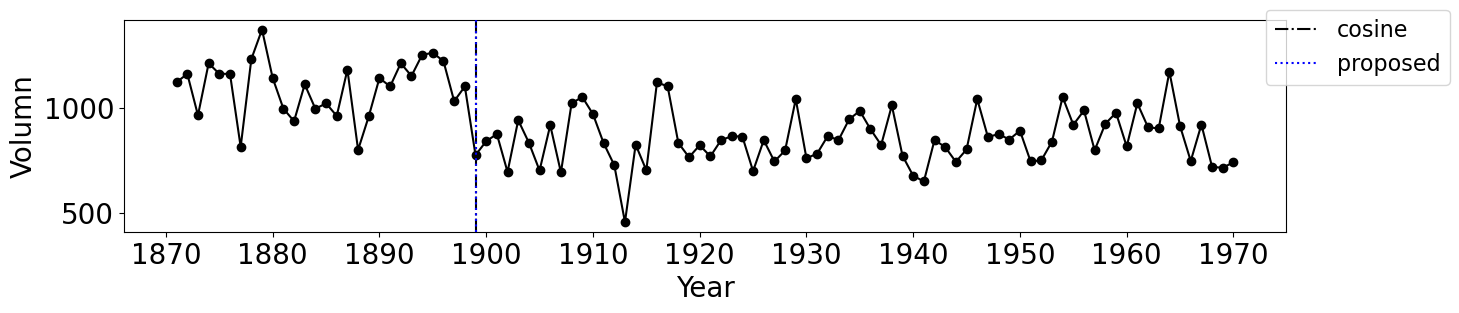

In [31]:
chosen_methods = ["cosine", "proposed"]
chpnts_dict_final = {k: chpnts_dict[k] for k in chosen_methods if k in chpnts_dict}

linestyles = {
    "label": "-",
    "linear": ":",
    "rbf": "--",
    "cosine": "-.",
    "proposed": ":",
}

plt.figure(figsize=(15, 2.75))
plt.scatter(
    df_plot["Year"],
    signal,
    color='black'
)
plt.plot(
    df_plot["Year"],
    signal,
    color='black'
)
plt.xlabel("Year", fontsize=20)
plt.ylabel("Volumn", fontsize=20)

ax = plt.gca()

for method, cp in chpnts_dict_final.items():
    plt.axvline(
        df_plot["Year"].iloc[cp],
        linestyle = linestyles.get(method, "--"),
        color = "red" if method == "label" else "blue" if method == "proposed"  else "black",
        zorder = 0    if method == "label" else 0 if method =="propose" else 15,
        label = method
    )
ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=13))

# remove duplicate legend entries
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc="upper right", bbox_to_anchor=(1.15, 1.1), fontsize=16)
plt.tick_params(axis='both', labelsize=20)
plt.show()